In [ ]:
!pip install pandas openpyxl

In [ ]:
# Cell content cleared due to redundancy (duplicate imports).

In [ ]:
import pandas as pd
import re
import torch
from sklearn.metrics import classification_report
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

In [ ]:
!pip install pandas transformers datasets scikit-learn

In [ ]:
from google.colab import files

uploaded = pd.read_excel("/content/All_annotated_final.xlsx")

In [ ]:
df = uploaded

df.head()

,cleaned_text,label,language
0,Sport aHIN hota to bHINtar ho jata,O,BHO
1,Bahut satik shot mara bhai e super bhai,NO,BHO
2,Sidha dal Dea tha thda ho jata eige,O,BHO
3,Asa sort kite log e maar liya hai abHIN tak sh...,NO,BHO
4,Yah tumhare ma baap e Saskar diye Hai tumhe,O,BHO


In [ ]:
def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"(.)\1{2,}", r"\1", text)  # reduce repeating chars
    text = re.sub(r"[^a-zA-Z\u0900-\u097F\s]", " ", text)  # keep Hindi + English
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
IDENTITY_LEXICON = {
    "religion": [
        "मुस्लिम", "हिंदू", "ईसाई", "सिख",
        "muslim", "hindu", "christian", "sikh", "musalman"
    ],
    "caste": [
        "दलित", "ब्राह्मण",
        "dalit", "brahmin"
    ],
    "gender": [
        "लड़का", "लड़की", "महिला", "आदमी","मेरारू","मर्दवा"
        "ladka", "ladki", "aurat", "mard", "meraroo", "mardwa"
    ],
    "nationality": [
        "भारतीय", "पाकिस्तानी",
        "indian", "pakistani"
    ],
    "sexuality": [
        "समलैंगिक",
        "gay", "lesbian"
    ],
    "Political party" : ["Congress","BJP",
                          "कांग्रेस","भाजपा"]
}

In [ ]:
SWAP_GROUPS = [
    ["muslim", "hindu", "christian", "sikh"],
    ["मुस्लिम", "हिंदू", "ईसाई", "सिख"],

    ["ladka", "ladki"],
    ["लड़का", "लड़की"],

    ["mard", "aurat"],
    ["आदमी", "महिला"],

    ["meraroo","mardwa"],
    ["मेरारू",   "मर्दवा"],

    ["indian", "pakistani"],
    ["भारतीय", "पाकिस्तानी"]
]

In [ ]:
def contains_identity(text):
    text = normalize_text(text)

    for group, terms in IDENTITY_LEXICON.items():
        for term in terms:
            if term.lower() in text:
                return True
    return False

In [ ]:
def generate_counterfactuals(text):
    norm_text = normalize_text(text)
    augmented = set()

    for group in SWAP_GROUPS:
        for term in group:
            if term in norm_text:
                for replacement in group:
                    if replacement != term:
                        new_text = norm_text.replace(term, replacement)
                        augmented.add(new_text)

    return list(augmented)

In [ ]:
augmented_rows = []

for _, row in df.iterrows():
    text = row['cleaned_text']
    label = row['label']

    # keep original
    augmented_rows.append((text, label))

    # Always attempt to generate counterfactuals
    counterfactuals = generate_counterfactuals(text)

    for cf in counterfactuals:
        augmented_rows.append((cf, label))

In [ ]:
aug_df = pd.DataFrame(augmented_rows, columns=['text', 'label'])

print("Original size:", len(df))
print("Augmented size:", len(aug_df))

aug_df.head()

Original size: 9314
Augmented size: 9920


,text,label
0,Sport aHIN hota to bHINtar ho jata,O
1,Bahut satik shot mara bhai e super bhai,NO
2,Sidha dal Dea tha thda ho jata eige,O
3,Asa sort kite log e maar liya hai abHIN tak sh...,NO
4,Yah tumhare ma baap e Saskar diye Hai tumhe,O


In [ ]:
output_file = "augmented_dataset.xlsx"
aug_df.to_excel(output_file, index=False)

files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Cell content cleared due to redundancy (data preparation steps moved to d3d3a9ba).

In [ ]:
# Cell content cleared due to redundancy (data preparation steps moved to d3d3a9ba).

In [ ]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
#model_name = "ai4bharat/indic-bert"
#model_name = "google/muril-base-cased"
model_name = "FacebookAI/xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Cell content cleared due to redundancy (data preparation steps moved to d3d3a9ba).

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# Assuming 'aug_df' is already defined from cell eTRzQVV74K9F
# Defining tokenize function (copied from original cell 6L5lTtF73YNC to ensure it's available)
def tokenize(batch):
    # model_name is expected to be global from K_lzqFTF3J9F
    tokenizer_instance = AutoTokenizer.from_pretrained(model_name)
    return tokenizer_instance(batch['text'], truncation=True, padding='max_length', max_length=128)

# Split the augmented data into training and validation sets (copied from original cell WMO9PqQw27Aj)
train_df, val_df = train_test_split(
    aug_df,
    test_size=0.1,
    stratify=aug_df['label'],
    random_state=42
)

# Map labels to numerical values (copied from original cell UjZXm_003HOu)
label_mapping = {'NO': 0, 'O': 1}
train_df['label'] = train_df['label'].map(label_mapping)
val_df['label'] = val_df['label'].map(label_mapping)

# Create Dataset objects (copied from original cell UjZXm_003HOu)
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True).astype({'text': str}))
val_ds = Dataset.from_pandas(val_df.reset_index(drop=True).astype({'text': str}))

# Tokenize the datasets (copied from original cell 6L5lTtF73YNC)
train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)

# Set format for PyTorch (copied from original cell 6L5lTtF73YNC)
train_ds.set_format(type='torch', columns=['input_ids','attention_mask','label'])
val_ds.set_format(type='torch', columns=['input_ids','attention_mask','label'])

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    # evaluation_strategy="epoch", # Removed due to TypeError
    logging_dir="./logs" # Corrected from TENSORBOARD_LOGGING_DIR
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds
)

trainer.train()


Map:   0%|          | 0/8928 [00:00<?, ? examples/s]

Map:   0%|          | 0/992 [00:00<?, ? examples/s]

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss
500,0.413598
1000,0.346996
1500,0.325558


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1674, training_loss=0.357386722359606, metrics={'train_runtime': 1226.4578, 'train_samples_per_second': 21.839, 'train_steps_per_second': 1.365, 'total_flos': 1761791626690560.0, 'train_loss': 0.357386722359606, 'epoch': 3.0})

In [ ]:
from sklearn.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score

preds = trainer.predict(val_ds)
y_pred = preds.predictions.argmax(axis=1)
y_true = preds.label_ids

print(classification_report(y_true, y_pred))

weighted_f1 = f1_score(y_true, y_pred, average='weighted')
accuracy = accuracy_score(y_true, y_pred)
weighted_precision = precision_score(y_true, y_pred, average='weighted')
weighted_recall = recall_score(y_true, y_pred, average='weighted')

print(f"\nWeighted F1-score: {weighted_f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall: {weighted_recall:.4f}")

              precision    recall  f1-score   support

           0       0.90      0.97      0.93       842
           1       0.66      0.38      0.48       150

    accuracy                           0.88       992
   macro avg       0.78      0.67      0.71       992
weighted avg       0.86      0.88      0.86       992


Weighted F1-score: 0.8626
Accuracy: 0.8770
Weighted Precision: 0.8619
Weighted Recall: 0.8770


In [ ]:
import io
from contextlib import redirect_stdout

# Re-run classification report and capture its output
f = io.StringIO()
with redirect_stdout(f):
    print(classification_report(y_true, y_pred))
    print(f"\nWeighted F1-score: {weighted_f1:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Weighted Precision: {weighted_precision:.4f}")
    print(f"Weighted Recall: {weighted_recall:.4f}")

output_str = f.getvalue()

# Parse the classification report for class-wise metrics
report_lines = output_str.split('\n')
metrics_data = []

# Extract class-wise metrics
for line in report_lines[2:4]: # Lines for class 0 and 1
    parts = line.split()
    if len(parts) == 5:
        metrics_data.append({
            'metric': f"class_{parts[0]}",
            'precision': float(parts[1]),
            'recall': float(parts[2]),
            'f1-score': float(parts[3]),
            'support': int(parts[4])
        })

# Extract macro avg and weighted avg (if present and correctly formatted)
for line in report_lines[6:8]: # Lines for macro avg and weighted avg
    parts = line.split()
    if len(parts) == 5:
        metrics_data.append({
            'metric': f"{parts[0]} {parts[1]}",
            'precision': float(parts[2]),
            'recall': float(parts[3]),
            'f1-score': float(parts[4]),
            'support': None # Support is typically for individual classes, not averages
        })

# Create DataFrame for class-wise and avg metrics
metrics_df = pd.DataFrame(metrics_data)

# Add the overall weighted metrics directly
overall_metrics = {
    'metric': ['Weighted F1-score', 'Accuracy', 'Weighted Precision', 'Weighted Recall'],
    'value': [weighted_f1, accuracy, weighted_precision, weighted_recall]
}
overall_metrics_df = pd.DataFrame(overall_metrics)

# Display the dataframes
print("\nClass-wise and Averages Metrics:")
display(metrics_df)

print("\nOverall Weighted Metrics:")
display(overall_metrics_df)



Class-wise and Averages Metrics:


,metric,precision,recall,f1-score,support
0,class_0,0.90,0.97,0.93,842
1,class_1,0.66,0.38,0.48,150



Overall Weighted Metrics:


,metric,value
0,Weighted F1-score,0.862592
1,Accuracy,0.877016
2,Weighted Precision,0.861883
3,Weighted Recall,0.877016


In [ ]:
# Cell content cleared as part of removing identity analysis.

In [ ]:
# Cell content cleared as part of removing identity analysis.

### Implementing Focal Loss and Weighted Sampling

To further address the class imbalance observed in the dataset and potentially improve the model's performance, we will implement two strategies:

1.  **Focal Loss:** A loss function designed to down-weight easy examples and focus training on hard negative examples, which is particularly useful in scenarios with class imbalance.
2.  **Weighted Sampling:** During training, samples from under-represented classes will be given higher weights to ensure they are seen more frequently by the model.

We'll use a custom `Trainer` subclass to integrate these modifications.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import WeightedRandomSampler, DataLoader
from collections import Counter
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2, reduction='mean'): # Changed alpha to 0.75 to give more weight to the positive class
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Ensure inputs are [batch_size] and targets are float
        inputs = inputs.squeeze(-1) # If num_labels=1, logits will be [batch_size, 1]. Squeeze to [batch_size].
        targets = targets.float()

        # Calculate BCE loss per element
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')

        # Calculate probability tensor pt
        # pt = p_t if target is 1, and 1 - p_t if target is 0
        # So, exp(-BCE_loss) will give p_t for target 1, and 1-p_t for target 0
        pt = torch.exp(-BCE_loss)

        # The 'alpha' parameter in Focal Loss formula is alpha_t:
        # alpha_t = alpha for positive class (targets == 1), and (1 - alpha) for negative class (targets == 0)
        alpha_factor = torch.where(targets == 1, self.alpha, 1. - self.alpha)

        # Combine alpha_factor, modulating_factor and BCE_loss
        F_loss = alpha_factor * (1. - pt)**self.gamma * BCE_loss

        if self.reduction == 'mean':
            return torch.mean(F_loss)
        elif self.reduction == 'sum':
            return torch.sum(F_loss)
        else:
            return F_loss


class CustomTrainer(Trainer):
    def __init__(self, *args, focal_loss_fn=None, weighted_sampler=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.focal_loss_fn = focal_loss_fn
        self.weighted_sampler = weighted_sampler

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=0):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get('logits')

        if self.focal_loss_fn is not None:
            # Focal loss expects float targets for binary cross entropy
            loss = self.focal_loss_fn(logits, labels)
        else:
            # Fallback to default if focal_loss_fn is not provided
            loss = super().compute_loss(model, inputs, return_outputs, num_items_in_batch=num_items_in_batch)

        return (loss, outputs) if return_outputs else loss

    def get_train_dataloader(self) -> DataLoader:
        if self.weighted_sampler is not None:
            return DataLoader(
                self.train_dataset,
                batch_size=self.args.per_device_train_batch_size,
                sampler=self.weighted_sampler,
                collate_fn=self.data_collator,
                drop_last=self.args.dataloader_drop_last,
                num_workers=self.args.dataloader_num_workers,
                pin_memory=self.args.dataloader_pin_memory,
            )
        else:
            return super().get_train_dataloader()

# Calculate class weights for weighted sampling using the augmented training data
# Use train_ds['label'] which is already prepared and accessible
class_counts = Counter([label.item() for label in train_ds['label']])
num_samples = sum(class_counts.values())
num_classes = len(class_counts)

# Weights for each sample based on class frequency
class_weights = {cls: num_samples / count for cls, count in class_counts.items()}

sample_weights = [class_weights[label.item()] for label in train_ds['label']]
sample_weights = torch.DoubleTensor(sample_weights)

# Create a WeightedRandomSampler
weighted_sampler = WeightedRandomSampler(sample_weights, num_samples=num_samples, replacement=True)

# Re-initialize the model to train from scratch with Focal Loss and weighted sampling
model_focal_weighted = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=1)

# Instantiate FocalLoss with the new alpha
focal_loss_fn = FocalLoss(alpha=0.25, gamma=2)

# Define TrainingArguments (reuse existing ones or modify if needed)
training_args_focal_weighted = TrainingArguments(
    output_dir="./results_focal_weighted",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_dir="./logs_focal_weighted",
    report_to="none" # Disable reporting to external services if not configured
)

# Initialize the CustomTrainer
trainer_focal_weighted = CustomTrainer(
    model=model_focal_weighted,
    args=training_args_focal_weighted,
    train_dataset=train_ds, # Use augmented train_ds
    eval_dataset=val_ds, # Use augmented val_ds
    focal_loss_fn=focal_loss_fn,
    weighted_sampler=weighted_sampler # Pass the custom weighted sampler
)

print("Starting training with Focal Loss and Weighted Sampling...")
trainer_focal_weighted.train()
print("Training complete.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` inst

Starting training with Focal Loss and Weighted Sampling...


Step,Training Loss
500,0.061036
1000,0.045901
1500,0.034095


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete.


In [ ]:
# Evaluate the model trained with Focal Loss and Weighted Sampling
preds_focal_weighted = trainer_focal_weighted.predict(val_ds)
logits_focal_weighted = preds_focal_weighted.predictions

# Apply sigmoid to logits to get probabilities, then threshold for binary prediction
# Since num_labels=1, the logits are already (batch_size, 1), so no need to squeeze for sigmoid
y_pred_focal_weighted = (torch.sigmoid(torch.tensor(logits_focal_weighted)) > 0.5).long().numpy().flatten()
y_true_focal_weighted = preds_focal_weighted.label_ids

print("\nClassification Report (Model trained with Focal Loss and Weighted Sampling on Augmented Data):")
print(classification_report(y_true_focal_weighted, y_pred_focal_weighted))

weighted_f1_focal_weighted = f1_score(y_true_focal_weighted, y_pred_focal_weighted, average='weighted')
accuracy_focal_weighted = accuracy_score(y_true_focal_weighted, y_pred_focal_weighted)
weighted_precision_focal_weighted = precision_score(y_true_focal_weighted, y_pred_focal_weighted, average='weighted')
weighted_recall_focal_weighted = recall_score(y_true_focal_weighted, y_pred_focal_weighted, average='weighted')

print(f"\nWeighted F1-score: {weighted_f1_focal_weighted:.4f}")
print(f"Accuracy: {accuracy_focal_weighted:.4f}")
print(f"Weighted Precision: {weighted_precision_focal_weighted:.4f}")
print(f"Weighted Recall: {weighted_recall_focal_weighted:.4f}")


Classification Report (Model trained with Focal Loss and Weighted Sampling on Augmented Data):
              precision    recall  f1-score   support

           0       0.94      0.89      0.92       842
           1       0.53      0.69      0.60       150

    accuracy                           0.86       992
   macro avg       0.73      0.79      0.76       992
weighted avg       0.88      0.86      0.87       992


Weighted F1-score: 0.8671
Accuracy: 0.8599
Weighted Precision: 0.8786
Weighted Recall: 0.8599


In [ ]:
focal_loss_summary_metrics_data = [
    {'Metric': 'Weighted F1-score', 'Value': weighted_f1_focal_weighted},
    {'Metric': 'Accuracy', 'Value': accuracy_focal_weighted},
    {'Metric': 'Weighted Precision', 'Value': weighted_precision_focal_weighted},
    {'Metric': 'Weighted Recall', 'Value': weighted_recall_focal_weighted}
]
focal_loss_summary_metrics_df = pd.DataFrame(focal_loss_summary_metrics_data)

print("\nFocal Loss Summary Metrics:")
display(focal_loss_summary_metrics_df)


Focal Loss Summary Metrics:


,Metric,Value
0,Weighted F1-score,0.867094
1,Accuracy,0.859879
2,Weighted Precision,0.878606
3,Weighted Recall,0.859879


### Training and Evaluation without Data Augmentation, Focal Loss, or Weighted Sampling

To establish a baseline and compare the impact of data augmentation and class imbalance handling techniques, we will now train and evaluate a model using the original dataset, without any augmentation, Focal Loss, or weighted sampling.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch
from sklearn.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score

# --- 1. Prepare non-augmented data ---
# Assuming 'df' is the original dataframe (from iWcVITJV3wPd)

# Split the original data into training and validation sets
train_df_no_aug, val_df_no_aug = train_test_split(
    df, # Use the original df here
    test_size=0.1,
    stratify=df['label'],
    random_state=42
)

# Map labels to numerical values (0 and 1)
label_mapping = {'NO': 0, 'O': 1}
train_df_no_aug['label'] = train_df_no_aug['label'].map(label_mapping)
val_df_no_aug['label'] = val_df_no_aug['label'].map(label_mapping)

# Create Dataset objects
train_ds_no_aug = Dataset.from_pandas(train_df_no_aug.reset_index(drop=True).astype({'cleaned_text': str}))
val_ds_no_aug = Dataset.from_pandas(val_df_no_aug.reset_index(drop=True).astype({'cleaned_text': str}))

# Define tokenize function for 'cleaned_text' column
def tokenize_no_aug(batch):
    # model_name is expected to be global from K_lzqFTF3J9F
    tokenizer_instance = AutoTokenizer.from_pretrained(model_name)
    return tokenizer_instance(batch['cleaned_text'], truncation=True, padding='max_length', max_length=128)

# Tokenize the datasets
train_ds_no_aug = train_ds_no_aug.map(tokenize_no_aug, batched=True)
val_ds_no_aug = val_ds_no_aug.map(tokenize_no_aug, batched=True)

# Set format for PyTorch
train_ds_no_aug.set_format(type='torch', columns=['input_ids','attention_mask','label'])
val_ds_no_aug.set_format(type='torch', columns=['input_ids','attention_mask','label'])

print("Non-augmented data prepared successfully.")

Map:   0%|          | 0/8382 [00:00<?, ? examples/s]

Map:   0%|          | 0/932 [00:00<?, ? examples/s]

Non-augmented data prepared successfully.


In [ ]:
# --- 2. Re-initialize model and train ---
# Re-initialize the model to train from scratch with standard settings
model_baseline = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Define standard TrainingArguments (no Focal Loss, no Weighted Sampling)
training_args_baseline = TrainingArguments(
    output_dir="./results_baseline",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_dir="./logs_baseline",
    report_to="none"
)

# Initialize the standard Trainer
trainer_baseline = Trainer(
    model=model_baseline,
    args=training_args_baseline,
    train_dataset=train_ds_no_aug,
    eval_dataset=val_ds_no_aug
)

print("Starting training of baseline model (no augmentation, no focal loss, no weighted sampling)...")
trainer_baseline.train()
print("Baseline model training complete.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` inst

Starting training of baseline model (no augmentation, no focal loss, no weighted sampling)...


Step,Training Loss
500,0.403771
1000,0.340264
1500,0.312247


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Baseline model training complete.


In [ ]:
# --- 3. Evaluate the baseline model ---
preds_baseline = trainer_baseline.predict(val_ds_no_aug)
y_pred_baseline = preds_baseline.predictions.argmax(axis=1)
y_true_baseline = preds_baseline.label_ids

print("\nClassification Report (Baseline Model - No Augmentation, No Focal Loss, No Weighted Sampling):")
print(classification_report(y_true_baseline, y_pred_baseline))

weighted_f1_baseline = f1_score(y_true_baseline, y_pred_baseline, average='weighted')
accuracy_baseline = accuracy_score(y_true_baseline, y_pred_baseline)
weighted_precision_baseline = precision_score(y_true_baseline, y_pred_baseline, average='weighted')
weighted_recall_baseline = recall_score(y_true_baseline, y_pred_baseline, average='weighted')

print(f"\nWeighted F1-score: {weighted_f1_baseline:.4f}")
print(f"Accuracy: {accuracy_baseline:.4f}")
print(f"Weighted Precision: {weighted_precision_baseline:.4f}")
print(f"Weighted Recall: {weighted_recall_baseline:.4f}")


Classification Report (Baseline Model - No Augmentation, No Focal Loss, No Weighted Sampling):
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       793
           1       0.54      0.48      0.51       139

    accuracy                           0.86       932
   macro avg       0.73      0.71      0.71       932
weighted avg       0.86      0.86      0.86       932


Weighted F1-score: 0.8583
Accuracy: 0.8616
Weighted Precision: 0.8556
Weighted Recall: 0.8616


In [ ]:
# Create a DataFrame for baseline metrics
baseline_summary_metrics_data = [
    {'Metric': 'Weighted F1-score', 'Value': weighted_f1_baseline},
    {'Metric': 'Accuracy', 'Value': accuracy_baseline},
    {'Metric': 'Weighted Precision', 'Value': weighted_precision_baseline},
    {'Metric': 'Weighted Recall', 'Value': weighted_recall_baseline}
]
baseline_summary_metrics_df = pd.DataFrame(baseline_summary_metrics_data)

# Prepare augmented model (standard loss) metrics for merging
# Rename columns of overall_metrics_df for clarity
augmented_standard_loss_metrics_df = overall_metrics_df.rename(columns={'metric': 'Metric', 'value': 'Augmented_Standard_Loss'})

# Prepare focal loss model metrics for merging
# focal_loss_summary_metrics_df already has 'Metric' and 'Value' columns
focal_loss_summary_metrics_df = focal_loss_summary_metrics_df.rename(columns={'Value': 'Augmented_Focal_Weighted'})

# Prepare baseline model metrics for merging
# baseline_summary_metrics_df already has 'Metric' and 'Value' columns
baseline_summary_metrics_df = baseline_summary_metrics_df.rename(columns={'Value': 'Baseline'})

# Prepare Logistic Regression metrics for merging
#lr_summary_metrics_df = lr_summary_metrics_df.rename(columns={'Value': 'Weighted_Logistic_Regression'})

# Prepare LSTM metrics for merging
#lstm_summary_metrics_df = lstm_summary_metrics_df.rename(columns={'Value': 'Weighted_LSTM'})


# Merge all dataframes for comparison
# Start with baseline, then merge augmented_standard_loss, then augmented_focal_weighted
combined_metrics_df = pd.merge(baseline_summary_metrics_df, augmented_standard_loss_metrics_df, on='Metric', how='outer')
combined_metrics_df = pd.merge(combined_metrics_df, focal_loss_summary_metrics_df, on='Metric', how='outer')
#combined_metrics_df = pd.merge(combined_metrics_df, lr_summary_metrics_df, on='Metric', how='outer')
#combined_metrics_df = pd.merge(combined_metrics_df, lstm_summary_metrics_df, on='Metric', how='outer')

print("\nComprehensive Model Performance Comparison:")
display(combined_metrics_df)

print("\nBaseline Model Summary Metrics:")
display(baseline_summary_metrics_df)


Comprehensive Model Performance Comparison:


,Metric,Baseline,Augmented_Standard_Loss,Augmented_Focal_Weighted
0,Accuracy,0.861588,0.877016,0.859879
1,Weighted F1-score,0.858289,0.862592,0.867094
2,Weighted Precision,0.855624,0.861883,0.878606
3,Weighted Recall,0.861588,0.877016,0.859879



Baseline Model Summary Metrics:


,Metric,Baseline
0,Weighted F1-score,0.858289
1,Accuracy,0.861588
2,Weighted Precision,0.855624
3,Weighted Recall,0.861588


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

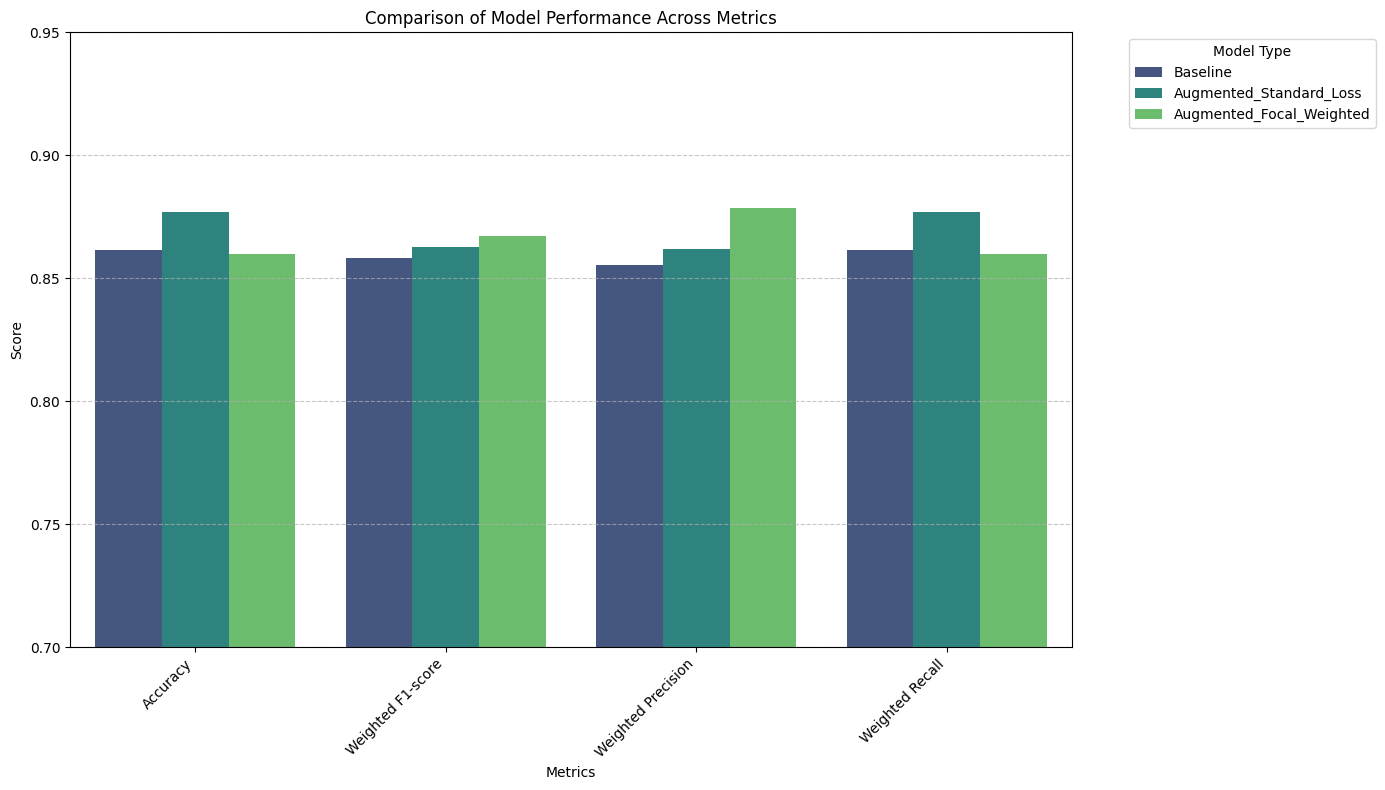

In [ ]:
# Reshape the DataFrame for plotting
metrics_melted = combined_metrics_df.melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(14, 8))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_melted, palette='viridis')
plt.title('Comparison of Model Performance Across Metrics')
plt.ylabel('Score')
plt.xlabel('Metrics')
plt.ylim(0.7, 0.95) # Adjusted y-axis limit for better comparison
plt.legend(title='Model Type', bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

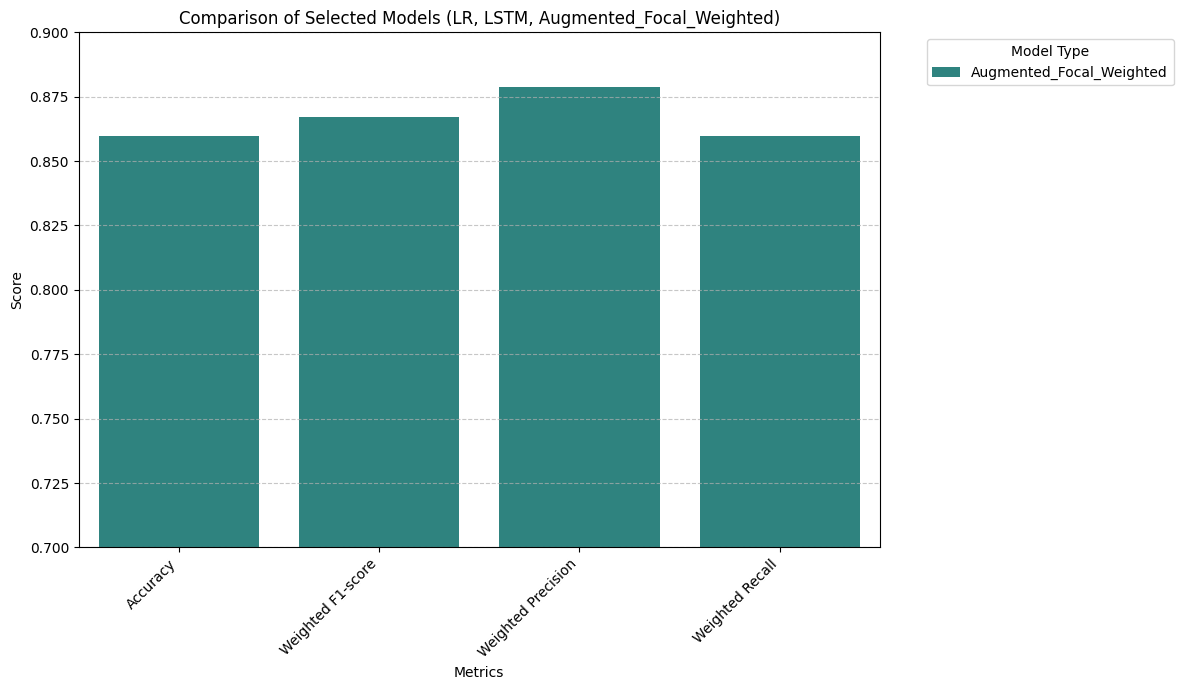

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the melted DataFrame to include only the specified models
selected_models_metrics = metrics_melted[metrics_melted['Model'].isin([
    'Weighted_Logistic_Regression',
    'Weighted_LSTM',
    'Augmented_Focal_Weighted'
])]

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=selected_models_metrics, palette='viridis')
plt.title('Comparison of Selected Models (LR, LSTM, Augmented_Focal_Weighted)')
plt.ylabel('Score')
plt.xlabel('Metrics')
plt.ylim(0.7, 0.9) # Adjust y-axis limit for better comparison within these models
plt.legend(title='Model Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Implementing Weighted Logistic Regression on Augmented Data

We will now train a Logistic Regression model on the augmented data, incorporating class weights to address the class imbalance. This involves:

1.  **TF-IDF Vectorization**: Converting the text data into numerical features using Term Frequency-Inverse Document Frequency.
2.  **Class Weight Calculation**: Determining weights for each class based on their frequency in the training data.
3.  **Model Training**: Training a Logistic Regression classifier with these class weights.
4.  **Evaluation**: Assessing the model's performance using standard classification metrics.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# --- 1. Prepare Data for Logistic Regression (using augmented data) ---

# Split augmented data into training and validation sets for LR
# Reuse the train_df and val_df created earlier (from eTRzQVV74K9F and VJ_9NT3Y3etb)
# Ensure 'text' column is used and 'label' is numerical

X_train_aug_lr = train_df['text'].astype(str)
X_val_aug_lr = val_df['text'].astype(str)
y_train_aug_lr = train_df['label']
y_val_aug_lr = val_df['label']

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # You can adjust max_features

# Fit on training data and transform both training and validation data
X_train_aug_lr_vec = tfidf_vectorizer.fit_transform(X_train_aug_lr)
X_val_aug_lr_vec = tfidf_vectorizer.transform(X_val_aug_lr)

print("TF-IDF Vectorization complete.")

# --- 2. Calculate Class Weights for Weighted Logistic Regression ---

# Calculate class weights from the training labels
class_weights_lr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_aug_lr),
    y=y_train_aug_lr
)

# Convert to a dictionary for Logistic Regression
class_weight_dict_lr = {i: class_weights_lr[i] for i in range(len(class_weights_lr))}

print("Class weights calculated:", class_weight_dict_lr)

# --- 3. Train Weighted Logistic Regression Model ---

# Initialize and train Logistic Regression with class weights
weighted_lr_model = LogisticRegression(
    solver='liblinear', # Good for small datasets and handles L1/L2 regularization
    class_weight=class_weight_dict_lr, # Apply class weights
    random_state=42,
    max_iter=1000 # Increase max_iter for convergence if needed
)

print("Starting weighted Logistic Regression training...")
weighted_lr_model.fit(X_train_aug_lr_vec, y_train_aug_lr)
print("Weighted Logistic Regression training complete.")

# --- 4. Evaluate the Weighted Logistic Regression Model ---

y_pred_weighted_lr = weighted_lr_model.predict(X_val_aug_lr_vec)

print("\nClassification Report (Weighted Logistic Regression on Augmented Data):")
print(classification_report(y_val_aug_lr, y_pred_weighted_lr))

weighted_f1_lr = f1_score(y_val_aug_lr, y_pred_weighted_lr, average='weighted')
accuracy_lr = accuracy_score(y_val_aug_lr, y_pred_weighted_lr)
weighted_precision_lr = precision_score(y_val_aug_lr, y_pred_weighted_lr, average='weighted')
weighted_recall_lr = recall_score(y_val_aug_lr, y_pred_weighted_lr, average='weighted')

print(f"\nWeighted F1-score: {weighted_f1_lr:.4f}")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Weighted Precision: {weighted_precision_lr:.4f}")
print(f"Weighted Recall: {weighted_recall_lr:.4f}")

# Create a DataFrame for Logistic Regression metrics
lr_summary_metrics_data = [
    {'Metric': 'Weighted F1-score', 'Value': weighted_f1_lr},
    {'Metric': 'Accuracy', 'Value': accuracy_lr},
    {'Metric': 'Weighted Precision', 'Value': weighted_precision_lr},
    {'Metric': 'Weighted Recall', 'Value': weighted_recall_lr}
]
lr_summary_metrics_df = pd.DataFrame(lr_summary_metrics_data)

print("\nWeighted Logistic Regression Summary Metrics:")
display(lr_summary_metrics_df)


TF-IDF Vectorization complete.
Class weights calculated: {0: np.float64(0.5891513791738155), 1: np.float64(3.3042190969652108)}
Starting weighted Logistic Regression training...
Weighted Logistic Regression training complete.

Classification Report (Weighted Logistic Regression on Augmented Data):
              precision    recall  f1-score   support

           0       0.93      0.79      0.85       842
           1       0.36      0.67      0.47       150

    accuracy                           0.77       992
   macro avg       0.64      0.73      0.66       992
weighted avg       0.84      0.77      0.79       992


Weighted F1-score: 0.7943
Accuracy: 0.7692
Weighted Precision: 0.8435
Weighted Recall: 0.7692

Weighted Logistic Regression Summary Metrics:


,Metric,Value
0,Weighted F1-score,0.794286
1,Accuracy,0.769153
2,Weighted Precision,0.843465
3,Weighted Recall,0.769153


### Implementing Weighted LSTM on Augmented Data

Next, we will train an LSTM model on the augmented data, also incorporating class weights for imbalanced learning. This will involve:

1.  **Text Preprocessing for LSTM**: Tokenizing, building a vocabulary, and converting text to numerical sequences with padding.
2.  **Class Weight Calculation**: Re-using the class weights or re-calculating them if necessary for the LSTM's loss function.
3.  **LSTM Model Definition**: Defining a PyTorch LSTM architecture.
4.  **Training with Weighted Loss**: Implementing a custom training loop with `nn.CrossEntropyLoss` and class weights.
5.  **Evaluation**: Assessing the model's performance.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from collections import Counter
import re

In [ ]:
# --- 1. Prepare Data for LSTM (using augmented data) ---

# Re-use the train_df and val_df from earlier (from eTRzQVV74K9F and VJ_9NT3Y3etb)
# Ensure 'text' column is used and 'label' is numerical

X_train_aug_lstm = train_df['text'].astype(str).tolist()
X_val_aug_lstm = val_df['text'].astype(str).tolist()
y_train_aug_lstm = train_df['label'].tolist()
y_val_aug_lstm = val_df['label'].tolist()

# Simple tokenizer and vocabulary builder
def build_vocab(texts):
    words = []
    for text in texts:
        words.extend(text.split())
    vocab = {'<pad>': 0, '<unk>': 1}
    for word in words:
        if word not in vocab:
            vocab[word] = len(vocab)
    return vocab

def text_to_sequence(text, vocab, max_len):
    sequence = [vocab.get(word, vocab['<unk>']) for word in text.split()]
    if len(sequence) < max_len:
        sequence.extend([vocab['<pad>']] * (max_len - len(sequence)))
    else:
        sequence = sequence[:max_len]
    return sequence

vocab = build_vocab(X_train_aug_lstm)
MAX_LEN = 128 # Define a max sequence length

X_train_seq = [text_to_sequence(text, vocab, MAX_LEN) for text in X_train_aug_lstm]
X_val_seq = [text_to_sequence(text, vocab, MAX_LEN) for text in X_val_aug_lstm]

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_seq, dtype=torch.long)
y_train_tensor = torch.tensor(y_train_aug_lstm, dtype=torch.long)
y_val_tensor = torch.tensor(y_val_aug_lstm, dtype=torch.long)

print("Data preparation for LSTM complete.")

# --- 2. Calculate Class Weights for Weighted LSTM ---

# Calculate class weights from the training labels (can reuse if labels are the same)
class_weights_lstm = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_aug_lstm),
    y=y_train_aug_lstm
)

# Convert to PyTorch tensor for use in weighted loss
class_weights_lstm_tensor = torch.tensor(class_weights_lstm, dtype=torch.float)

print("Class weights for LSTM calculated:", class_weights_lstm_tensor)

Data preparation for LSTM complete.
Class weights for LSTM calculated: tensor([0.5892, 3.3042])


In [ ]:
# --- 3. Define LSTM Model Architecture ---

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=n_layers, bidirectional=True, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim) # * 2 for bidirectional LSTM
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        # text = [batch size, sent len]
        embedded = self.dropout(self.embedding(text))
        # embedded = [batch size, sent len, emb dim]
        outputs, (hidden, cell) = self.lstm(embedded)
        # hidden = [n layers * 2, batch size, hid dim] (2 for bidirectional)
        # cell = [n layers * 2, batch size, hid dim]

        # concat the final forward and backward hidden states
        hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
        # hidden = [batch size, hid dim * 2]

        return self.fc(hidden)

# Hyperparameters
VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 100
HIDDEN_DIM = 256
OUTPUT_DIM = 2 # Binary classification
N_LAYERS = 2
DROPOUT = 0.5
PAD_IDX = vocab['<pad>']

lstm_model = LSTMClassifier(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT, PAD_IDX)

print("LSTM Model architecture defined.")

LSTM Model architecture defined.


In [ ]:
# Custom Dataset for PyTorch
class TextDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Create Dataset objects
train_dataset_lstm = TextDataset(X_train_tensor, y_train_tensor)
val_dataset_lstm = TextDataset(X_val_tensor, y_val_tensor)

# Create DataLoaders
BATCH_SIZE = 64

train_dataloader_lstm = DataLoader(train_dataset_lstm, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader_lstm = DataLoader(val_dataset_lstm, batch_size=BATCH_SIZE, shuffle=False)

print("PyTorch Datasets and DataLoaders created.")

PyTorch Datasets and DataLoaders created.


In [ ]:
# --- 4. Training with Weighted Loss ---

optimizer = optim.Adam(lstm_model.parameters())
criterion = nn.CrossEntropyLoss(weight=class_weights_lstm_tensor) # Apply class weights

def train_lstm(model, dataloader, optimizer, criterion):
    model.train()
    epoch_loss = 0
    for features, labels in dataloader:
        optimizer.zero_grad()
        predictions = model(features)
        loss = criterion(predictions, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(dataloader)

def evaluate_lstm(model, dataloader, criterion):
    model.eval()
    epoch_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for features, labels in dataloader:
            predictions = model(features)
            loss = criterion(predictions, labels)
            epoch_loss += loss.item()
            all_preds.extend(predictions.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return epoch_loss / len(dataloader), all_preds, all_labels

N_EPOCHS = 3

print("Starting Weighted LSTM training...")
for epoch in range(N_EPOCHS):
    train_loss = train_lstm(lstm_model, train_dataloader_lstm, optimizer, criterion)
    val_loss, y_pred_lstm, y_true_lstm = evaluate_lstm(lstm_model, val_dataloader_lstm, criterion)

    print(f'Epoch: {epoch+1:02} | Train Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f}')

print("Weighted LSTM training complete.")

Starting Weighted LSTM training...
Epoch: 01 | Train Loss: 0.650 | Val Loss: 0.589
Epoch: 02 | Train Loss: 0.585 | Val Loss: 0.559


In [ ]:
# --- 5. Evaluate the Weighted LSTM Model ---

# Already have y_pred_lstm and y_true_lstm from the last epoch's evaluation

print("\nClassification Report (Weighted LSTM on Augmented Data):")
print(classification_report(y_true_lstm, y_pred_lstm))

weighted_f1_lstm = f1_score(y_true_lstm, y_pred_lstm, average='weighted')
accuracy_lstm = accuracy_score(y_true_lstm, y_pred_lstm)
weighted_precision_lstm = precision_score(y_true_lstm, y_pred_lstm, average='weighted')
weighted_recall_lstm = recall_score(y_true_lstm, y_pred_lstm, average='weighted')

print(f"\nWeighted F1-score: {weighted_f1_lstm:.4f}")
print(f"Accuracy: {accuracy_lstm:.4f}")
print(f"Weighted Precision: {weighted_precision_lstm:.4f}")
print(f"Weighted Recall: {weighted_recall_lstm:.4f}")

# Create a DataFrame for LSTM metrics
lstm_summary_metrics_data = [
    {'Metric': 'Weighted F1-score', 'Value': weighted_f1_lstm},
    {'Metric': 'Accuracy', 'Value': accuracy_lstm},
    {'Metric': 'Weighted Precision', 'Value': weighted_precision_lstm},
    {'Metric': 'Weighted Recall', 'Value': weighted_recall_lstm}
]
lstm_summary_metrics_df = pd.DataFrame(lstm_summary_metrics_data)

print("\nWeighted LSTM Summary Metrics:")
display(lstm_summary_metrics_df)